In [1]:
import pandas as pd
from  trading_agent_class import Trading_Agent
from plot_vrp import plot_vrp

In [2]:
vix_options = pd.read_csv("data/vix_options.csv",parse_dates=["as_of_date", "expiration_date"],)
vix_data = pd.read_csv("data/vix_data.csv", parse_dates=["Date"])
vvix_data = pd.read_csv("data/vvix_data.csv", parse_dates=["Date"])
spx_data = pd.read_csv("data/spx_data.csv", parse_dates=["Date"])

feed_start = "2024-01-01"
start_date = "2024-06-01"
end_date = "2026-05-01"

date_list = vix_data["Date"].unique()

In [6]:
Agents = [
    Trading_Agent(name="rv22", test_length=30, longterm_period=60, garch_look_back = 20, 
        VRP_rv22_threshold = 0.8, VRP_lt_threshold = 999, VRP_garch_threshold = 999),
    Trading_Agent(name="lt", test_length=30, longterm_period=60, garch_look_back = 20, 
        VRP_rv22_threshold = 999, VRP_lt_threshold = 0.8, VRP_garch_threshold = 999),
    Trading_Agent(name="garch", test_length=30, longterm_period=60, garch_look_back = 20, 
        VRP_rv22_threshold = 999, VRP_lt_threshold = 999, VRP_garch_threshold = 0.8),
]

for today in date_list:
    vix = vix_data[vix_data["Date"] == today]["Close"].item()
    vvix = vvix_data[vvix_data["Date"] == today]["Close"].item()
    spx = spx_data[spx_data["Date"] == today]["Close"].item()
    rv22 = spx_data[spx_data["Date"] == today]["RV22"].item()
    option_chain = vix_options[vix_options["as_of_date"] == today]

    for agent in Agents:
        agent.feed_data(vix,vvix,spx,rv22)
        if not option_chain.empty:
            trading_signal = agent.signal()
            agent.trade(option_chain, trading_signal)
            agent.calculate_pnl(option_chain, today, vix)


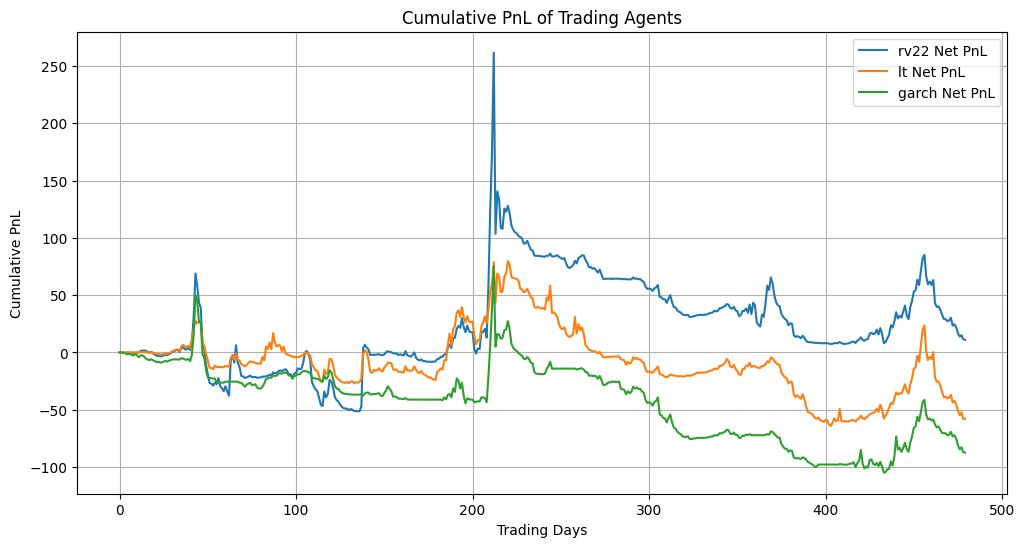

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
for agent in Agents:
    cum_pnl = agent.get_cum_pnl()
    plt.plot(cum_pnl, label=f"{agent.name} Net PnL")

plt.title("Cumulative PnL of Trading Agents")
plt.xlabel("Trading Days")
plt.ylabel("Cumulative PnL")
plt.legend()
plt.grid(True)
plt.show()


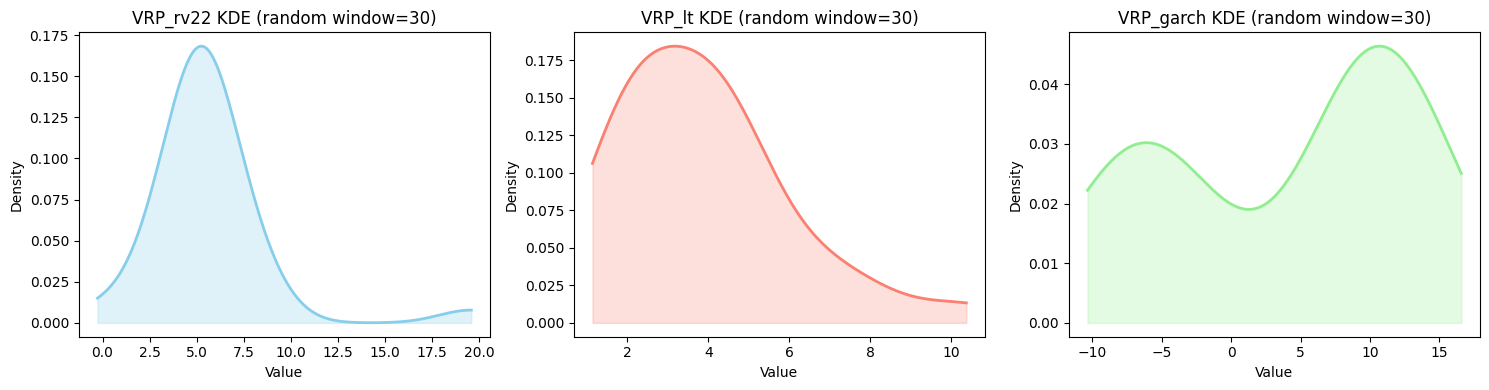

In [8]:
plot_vrp(Agents)